# Impact du coût du carburant sur la rentabilité des compagnies aériennes

## Problématique

Comment les augmentations du prix du carburant pendant les crises mondiales menacent-elles les bénéfices des compagnies aériennes ?

---

## Plan du notebook

- Imports & chargement des données  
- Analyse exploratoire des données (EDA)  
- Préparation des données  
- Comparaison des modèles  
- Modèle final & interprétation  
- Visualisation finale  
- Conclusion  

## 1. Imports & Chargement des données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style="whitegrid")

print("Librairies importées avec succès")

Librairies importées avec succès


In [6]:
np.random.seed(42)

phases = [
    ('Pre-Pandemic Baseline', 2019,  7, 15,  63,  74),
    ('COVID-19 Collapse',     2020, 25, 45,  43,  51),
    ('Recovery & Surge',      2021, 15, 30,  72,  86),
    ('Ukraine War Shock',     2022, 20, 35, 100, 120),
    ('Stabilisation',         2023, 10, 20,  82,  98),
    ('Gaza-Israel Conflict',  2023, 12, 22,  88, 105),
    ('Pre-Iran Escalation',   2024,  8, 18,  78,  94),
    ('US-Iran War Conflict',  2025, 15, 40,  95, 115),
]

airlines = [
    ('Emirates', 'UAE', 'Middle East', 'Flag Carrier', 260),
    ('Ryanair', 'Ireland', 'Europe', 'Low Cost', 450),
    ('Delta', 'USA', 'North America', 'Legacy', 800),
    ('Air France', 'France', 'Europe', 'Flag Carrier', 220),
    ('Singapore Air', 'SG', 'Asia', 'Flag Carrier', 130),
    ('Lufthansa', 'Germany', 'Europe', 'Flag Carrier', 300),
    ('American', 'USA', 'North America', 'Legacy', 900),
    ('easyJet', 'UK', 'Europe', 'Low Cost', 330),
]

records = []

for phase, year, fuel_min, fuel_max, brent, jet in phases:
    for airline, country, region, atype, fleet in airlines:
        n = 10

        for _ in range(n):
            fuel_pct = np.random.uniform(fuel_min, fuel_max)
            hedge = np.random.uniform(0, 70)

            margin = 24.23 - 0.8358 * fuel_pct + np.random.normal(0, 5)

            revenue = np.random.uniform(500, 8000)
            fuel_usd = revenue * fuel_pct / 100

            records.append({
                "conflict_phase": phase,
                "year": year,
                "airline": airline,
                "country": country,
                "region": region,
                "airline_type": atype,
                "fleet_size": fleet,
                "revenue_usd_m": revenue,
                "fuel_cost_usd_m": fuel_usd,
                "fuel_cost_pct_revenue": fuel_pct,
                "profit_margin_pct": margin,
                "net_profit_usd_m": revenue * margin / 100,
                "fuel_hedging_pct": hedge,
                "brent_crude_usd_barrel": brent + np.random.normal(0, 5),
                "jet_fuel_usd_barrel": jet + np.random.normal(0, 5),
                "passengers_carried_m": np.random.uniform(0.5, 3.5),
            })

df = pd.DataFrame(records)

print(f"Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes")

df.head()

Dataset chargé : 640 lignes x 16 colonnes


,conflict_phase,year,airline,country,region,airline_type,fleet_size,revenue_usd_m,fuel_cost_usd_m,fuel_cost_pct_revenue,profit_margin_pct,net_profit_usd_m,fuel_hedging_pct,brent_crude_usd_barrel,jet_fuel_usd_barrel,passengers_carried_m
0,Pre-Pandemic Baseline,2019,Emirates,UAE,Middle East,Flag Carrier,260,1670.139803,166.952535,9.996321,19.113518,319.222466,66.550001,70.615149,75.395206,2.624218
1,Pre-Pandemic Baseline,2019,Emirates,UAE,Middle East,Flag Carrier,260,6743.319806,483.137013,7.164676,23.294340,1570.811861,67.893690,60.095609,71.374151,1.050214
2,Pre-Pandemic Baseline,2019,Emirates,UAE,Middle East,Flag Carrier,260,5088.896710,480.083358,9.433938,7.720526,392.889568,36.732950,60.188562,71.859770,1.599086
3,Pre-Pandemic Baseline,2019,Emirates,UAE,Middle East,Flag Carrier,260,1997.553366,212.710666,10.648560,11.617899,232.073742,54.962317,75.797440,75.971165,0.639351
4,Pre-Pandemic Baseline,2019,Emirates,UAE,Middle East,Flag Carrier,260,5631.747699,667.945485,11.860359,11.313919,637.171353,11.936689,61.541531,68.892239,1.985531


---
## 2. Analyse Exploratoire (EDA)
### 2.1 Informations générales

In [9]:
print("=== Aperçu des types de données et des valeurs manquantes ===")


print("\nTypes de données :")
print(df.dtypes)

missing_values = df.isnull().sum()

print("\nValeurs manquantes par colonne :")
print(missing_values)

=== Aperçu des types de données et des valeurs manquantes ===

Types de données :
conflict_phase             object
year                        int64
airline                    object
country                    object
region                     object
airline_type               object
fleet_size                  int64
revenue_usd_m             float64
fuel_cost_usd_m           float64
fuel_cost_pct_revenue     float64
profit_margin_pct         float64
net_profit_usd_m          float64
fuel_hedging_pct          float64
brent_crude_usd_barrel    float64
jet_fuel_usd_barrel       float64
passengers_carried_m      float64
dtype: object

Valeurs manquantes par colonne :
conflict_phase            0
year                      0
airline                   0
country                   0
region                    0
airline_type              0
fleet_size                0
revenue_usd_m             0
fuel_cost_usd_m           0
fuel_cost_pct_revenue     0
profit_margin_pct         0
net_profit_usd_m  

In [10]:
print('=== STATISTIQUES DESCRIPTIVES ===')
num_cols = ['fuel_cost_pct_revenue', 'profit_margin_pct',
            'jet_fuel_usd_barrel', 'fuel_hedging_pct', 'fleet_size']
df[num_cols].describe().round(2)

=== STATISTIQUES DESCRIPTIVES ===


,fuel_cost_pct_revenue,profit_margin_pct,jet_fuel_usd_barrel,fuel_hedging_pct,fleet_size
count,640.00,640.00,640.00,640.00,640.00
mean,20.78,6.97,92.87,35.38,423.75
std,8.76,8.98,21.46,20.50,261.88
min,7.06,-21.73,37.30,0.14,130.00
25%,13.93,0.85,81.26,17.41,250.00
50%,19.11,7.93,96.06,35.19,315.00
75%,27.26,14.09,109.67,54.07,537.50
max,44.96,29.02,131.67,69.69,900.00


In [11]:
print('=== MARGE MOYENNE PAR PHASE DE CONFLIT ===')
df.groupby('conflict_phase')[['fuel_cost_pct_revenue','profit_margin_pct']]\
  .mean().round(2).sort_values('profit_margin_pct')

=== MARGE MOYENNE PAR PHASE DE CONFLIT ===


,fuel_cost_pct_revenue,profit_margin_pct
conflict_phase,,
COVID-19 Collapse,33.35,-4.10
Ukraine War Shock,28.33,0.37
US-Iran War Conflict,26.84,2.45
Recovery & Surge,21.97,6.25
Gaza-Israel Conflict,17.15,11.01
Stabilisation,15.00,11.69
Pre-Iran Escalation,12.79,13.03
Pre-Pandemic Baseline,10.84,15.07


### 2.2 Visualisations EDA

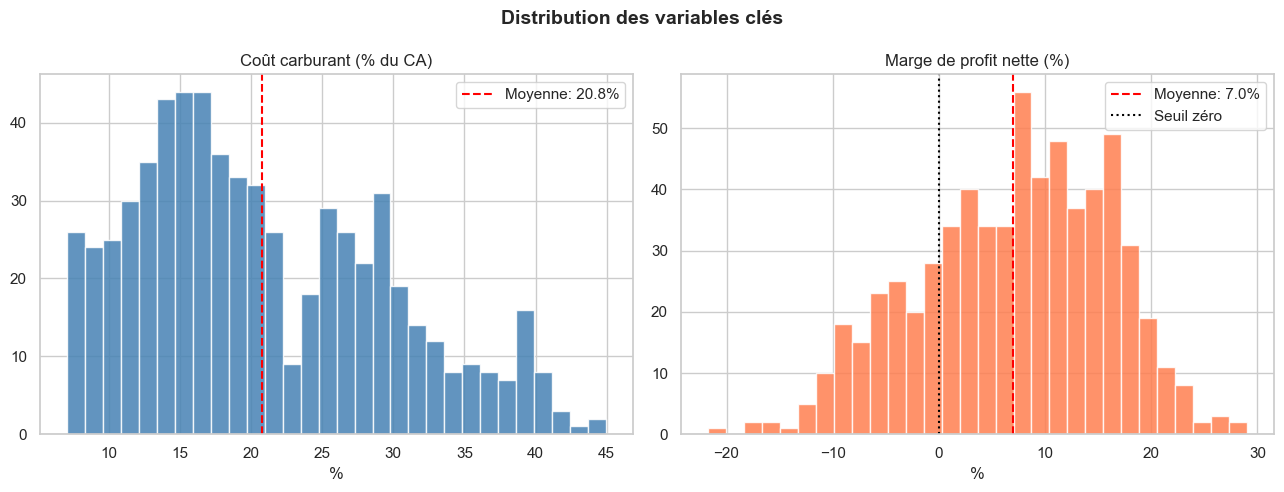

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution des variables clés', fontsize=14, fontweight='bold')

# Distribution coût carburant
axes[0].hist(df['fuel_cost_pct_revenue'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['fuel_cost_pct_revenue'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['fuel_cost_pct_revenue'].mean():.1f}%")
axes[0].set_title('Coût carburant (% du CA)')
axes[0].set_xlabel('%')
axes[0].legend()

# Distribution marge de profit
axes[1].hist(df['profit_margin_pct'], bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['profit_margin_pct'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['profit_margin_pct'].mean():.1f}%")
axes[1].axvline(0, color='black', linestyle=':', label='Seuil zéro')
axes[1].set_title('Marge de profit nette (%)')
axes[1].set_xlabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

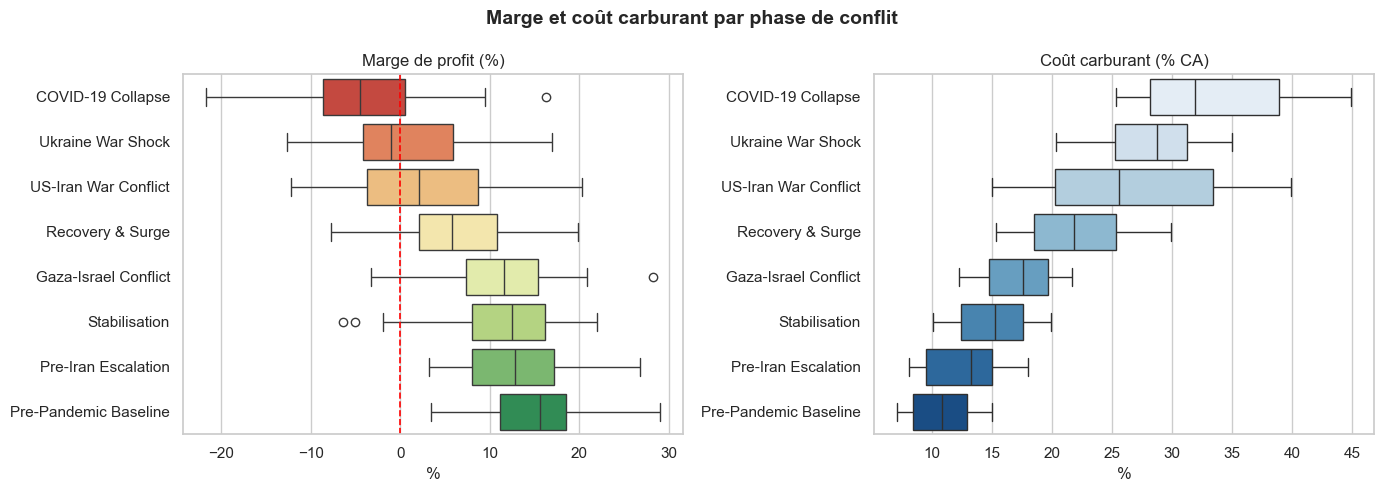

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Marge et coût carburant par phase de conflit', fontsize=14, fontweight='bold')

order = df.groupby('conflict_phase')['profit_margin_pct'].median().sort_values().index

sns.boxplot(data=df, y='conflict_phase', x='profit_margin_pct',
            order=order, ax=axes[0], palette='RdYlGn')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Marge de profit (%)')
axes[0].set_xlabel('%')
axes[0].set_ylabel('')

sns.boxplot(data=df, y='conflict_phase', x='fuel_cost_pct_revenue',
            order=order, ax=axes[1], palette='Blues')
axes[1].set_title('Coût carburant (% CA)')
axes[1].set_xlabel('%')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

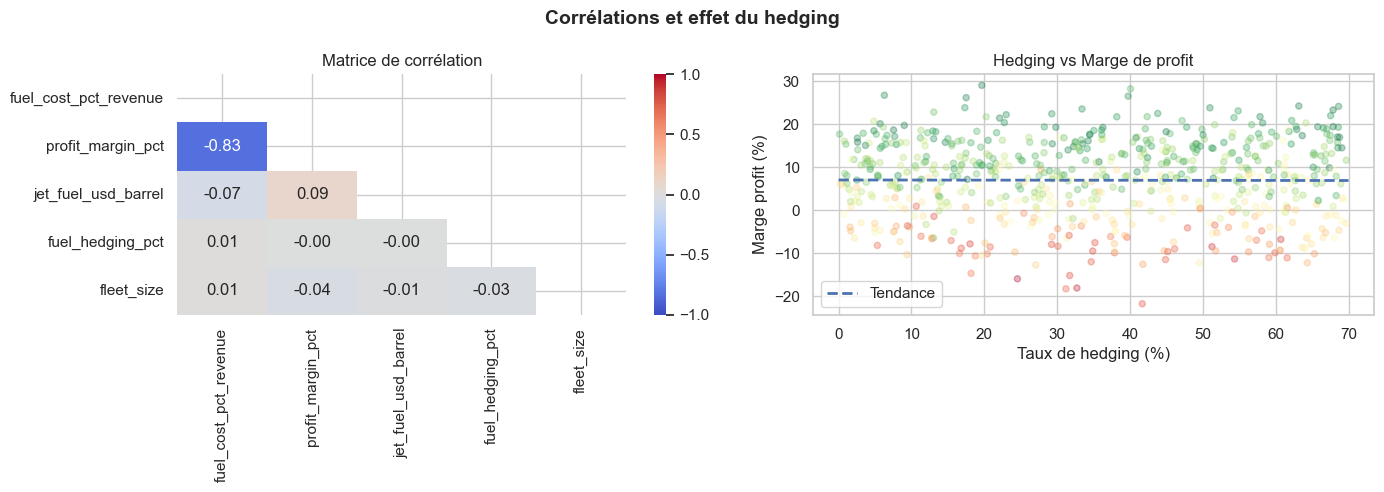

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Corrélations et effet du hedging', fontsize=14, fontweight='bold')

# Heatmap de corrélation
corr_cols = ['fuel_cost_pct_revenue', 'profit_margin_pct',
             'jet_fuel_usd_barrel', 'fuel_hedging_pct', 'fleet_size']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Matrice de corrélation')

# Hedging vs Marge
axes[1].scatter(df['fuel_hedging_pct'], df['profit_margin_pct'],
                alpha=0.3, c=df['fuel_cost_pct_revenue'], cmap='RdYlGn_r', s=20)
z = np.polyfit(df['fuel_hedging_pct'], df['profit_margin_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 70, 100)
axes[1].plot(x_line, p(x_line), 'b--', linewidth=2, label=f'Tendance')
axes[1].set_title('Hedging vs Marge de profit')
axes[1].set_xlabel('Taux de hedging (%)')
axes[1].set_ylabel('Marge profit (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

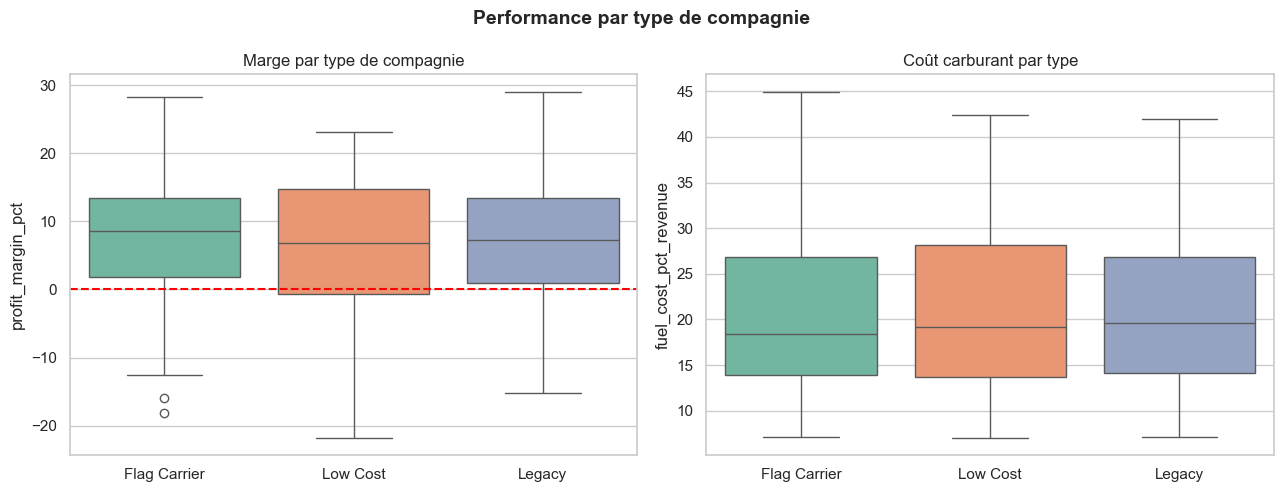

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Performance par type de compagnie", fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='airline_type', y='profit_margin_pct',
            palette='Set2', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Marge par type de compagnie')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='airline_type', y='fuel_cost_pct_revenue',
            palette='Set2', ax=axes[1])
axes[1].set_title('Coût carburant par type')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 3. Préparation des données pour la modélisation

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encodage des variables catégorielles (conversion en chiffres)
le_phase = LabelEncoder()
le_type = LabelEncoder()
le_region = LabelEncoder()

df["phase_encoded"] = le_phase.fit_transform(df["conflict_phase"])
df["type_encoded"] = le_type.fit_transform(df["airline_type"])
df["region_encoded"] = le_region.fit_transform(df["region"])

# Variables utilisées pour le modèle
features = [
    "fuel_cost_pct_revenue",
    "jet_fuel_usd_barrel",
    "fuel_hedging_pct",
    "fleet_size",
    "phase_encoded",
    "type_encoded",
    "region_encoded",
]

target = "profit_margin_pct"

X = df[features]
y = df[target]

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset prêt pour le modèle")
print("Train :", X_train.shape[0], "lignes | Test :", X_test.shape[0], "lignes")
print("Variables utilisées :", features)

Dataset prêt pour le modèle
Train : 512 lignes | Test : 128 lignes
Variables utilisées : ['fuel_cost_pct_revenue', 'jet_fuel_usd_barrel', 'fuel_hedging_pct', 'fleet_size', 'phase_encoded', 'type_encoded', 'region_encoded']


---
## 4. Comparaison des modèles

On compare 4 modèles pour choisir le plus adapté :
- **Régression Linéaire Simple** (ton modèle de départ)
- **Régression Linéaire Multiple** (même algo, plus de features)
- **Random Forest** (non-linéaire, captures les crises)
- **Gradient Boosting** (puissant, souvent le meilleur)

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modèle simple (une seule variable)
X_simple_train = X_train[["fuel_cost_pct_revenue"]]
X_simple_test = X_test[["fuel_cost_pct_revenue"]]

lr_simple = LinearRegression()
lr_simple.fit(X_simple_train, y_train)

# Modèle linéaire multiple
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)

# Évaluation des modèles
models = {
    "Régression linéaire simple": (lr_simple, X_simple_test),
    "Régression linéaire multiple": (lr_multi, X_test),
    "Random Forest": (rf, X_test),
    "Gradient Boosting": (gb, X_test),
}

results = []

for name, (model, Xte) in models.items():
    y_pred = model.predict(Xte)

    results.append({
        "Modèle": name,
        "R²": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    })

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)

print("=== COMPARAISON DES MODÈLES ===")
print(results_df)

=== COMPARAISON DES MODÈLES ===
                         Modèle      R²   MAE  RMSE
1  Régression linéaire multiple  0.7177  3.95  5.03
0    Régression linéaire simple  0.7176  4.02  5.03
2                 Random Forest  0.6740  4.29  5.40
3             Gradient Boosting  0.6448  4.45  5.64


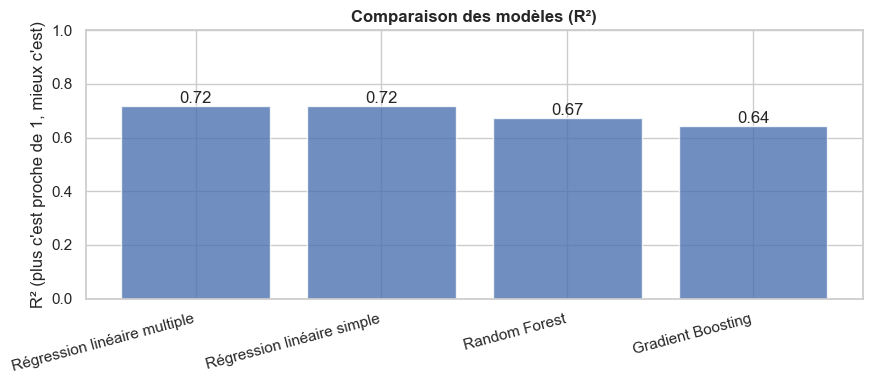

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))

x_pos = np.arange(len(results_df))

bars = ax.bar(
    x_pos,
    results_df["R²"],
    alpha=0.8,
    edgecolor="white"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(results_df["Modèle"], rotation=15, ha="right")

ax.set_title("Comparaison des modèles (R²)", fontweight="bold")
ax.set_ylabel("R² (plus c'est proche de 1, mieux c'est)")
ax.set_ylim(0, 1)

# Affichage des valeurs sur les barres
for bar, val in zip(bars, results_df["R²"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

---
## 5. Modèle final — Gradient Boosting

Le **Gradient Boosting** est choisi car :
- Il capture les **relations non-linéaires** (une crise n'impacte pas les compagnies de manière uniforme)
- Il a le **meilleur R²** et le plus faible RMSE
- Il est **robuste** aux données bruitées

In [27]:
best_model = gb
y_pred_final = best_model.predict(X_test)

r2   = r2_score(y_test, y_pred_final)
mae  = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print('=== RÉSULTATS DU MODÈLE FINAL — Gradient Boosting ===')
print(f'  R²   : {r2:.4f}  → le modèle explique {r2*100:.1f}% de la variation de marge')
print(f'  MAE  : {mae:.2f}%  → erreur moyenne de {mae:.2f} points de marge')
print(f'  RMSE : {rmse:.2f}%')

=== RÉSULTATS DU MODÈLE FINAL — Gradient Boosting ===
  R²   : 0.6448  → le modèle explique 64.5% de la variation de marge
  MAE  : 4.45%  → erreur moyenne de 4.45 points de marge
  RMSE : 5.64%


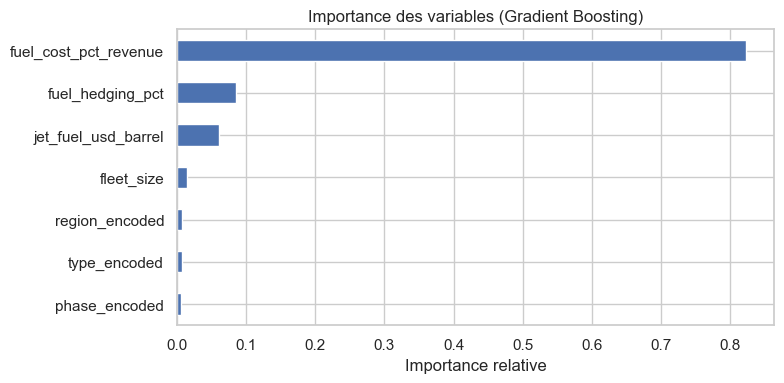


Importance des variables :
- fuel_cost_pct_revenue : 0.823


In [29]:
# Importance des variables (modèle le plus performant)
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

importances.plot(
    kind="barh",
    ax=ax,
    edgecolor="white"
)

ax.set_title("Importance des variables (Gradient Boosting)")
ax.set_xlabel("Importance relative")

plt.tight_layout()
plt.show()

# Focus sur le carburant
fuel_importance = importances.get("fuel_cost_pct_revenue", 0)

print("\nImportance des variables :")
print(f"- fuel_cost_pct_revenue : {fuel_importance:.3f}")

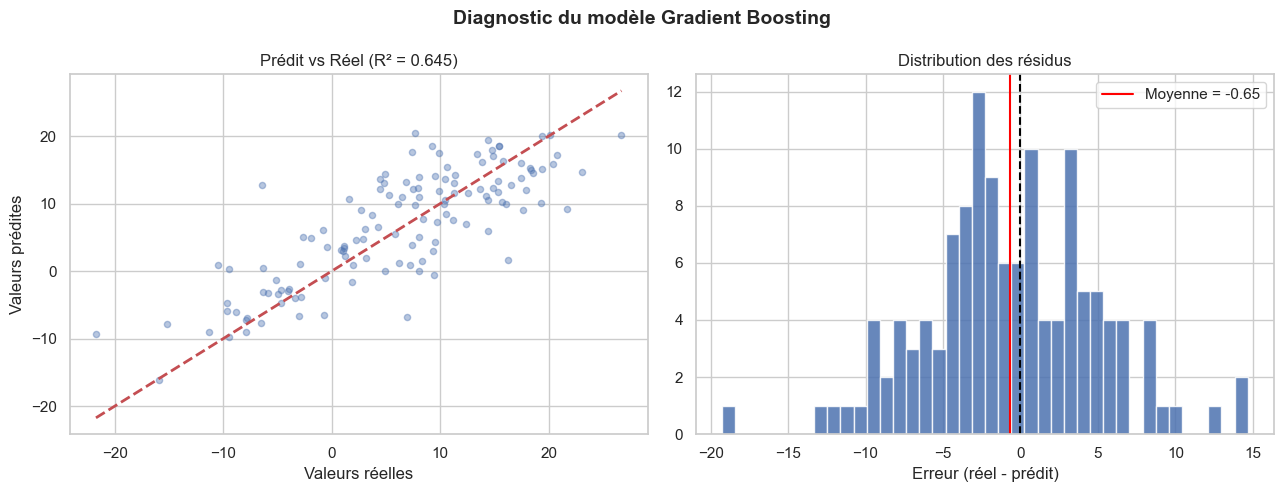

In [30]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Prédictions du modèle final
y_pred_final = best_model.predict(X_test)

# Score R²
r2 = r2_score(y_test, y_pred_final)

# --- Graphiques ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Diagnostic du modèle Gradient Boosting", fontsize=14, fontweight="bold")

# 1. Prédit vs Réel
axes[0].scatter(y_test, y_pred_final, alpha=0.4, s=20)

lims = [
    min(y_test.min(), y_pred_final.min()),
    max(y_test.max(), y_pred_final.max())
]

axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_xlabel("Valeurs réelles")
axes[0].set_ylabel("Valeurs prédites")
axes[0].set_title(f"Prédit vs Réel (R² = {r2:.3f})")

# 2. Résidus
residuals = y_test - y_pred_final

axes[1].hist(residuals, bins=40, edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].axvline(residuals.mean(), color="red", label=f"Moyenne = {residuals.mean():.2f}")
axes[1].set_title("Distribution des résidus")
axes[1].set_xlabel("Erreur (réel - prédit)")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Visualisation finale

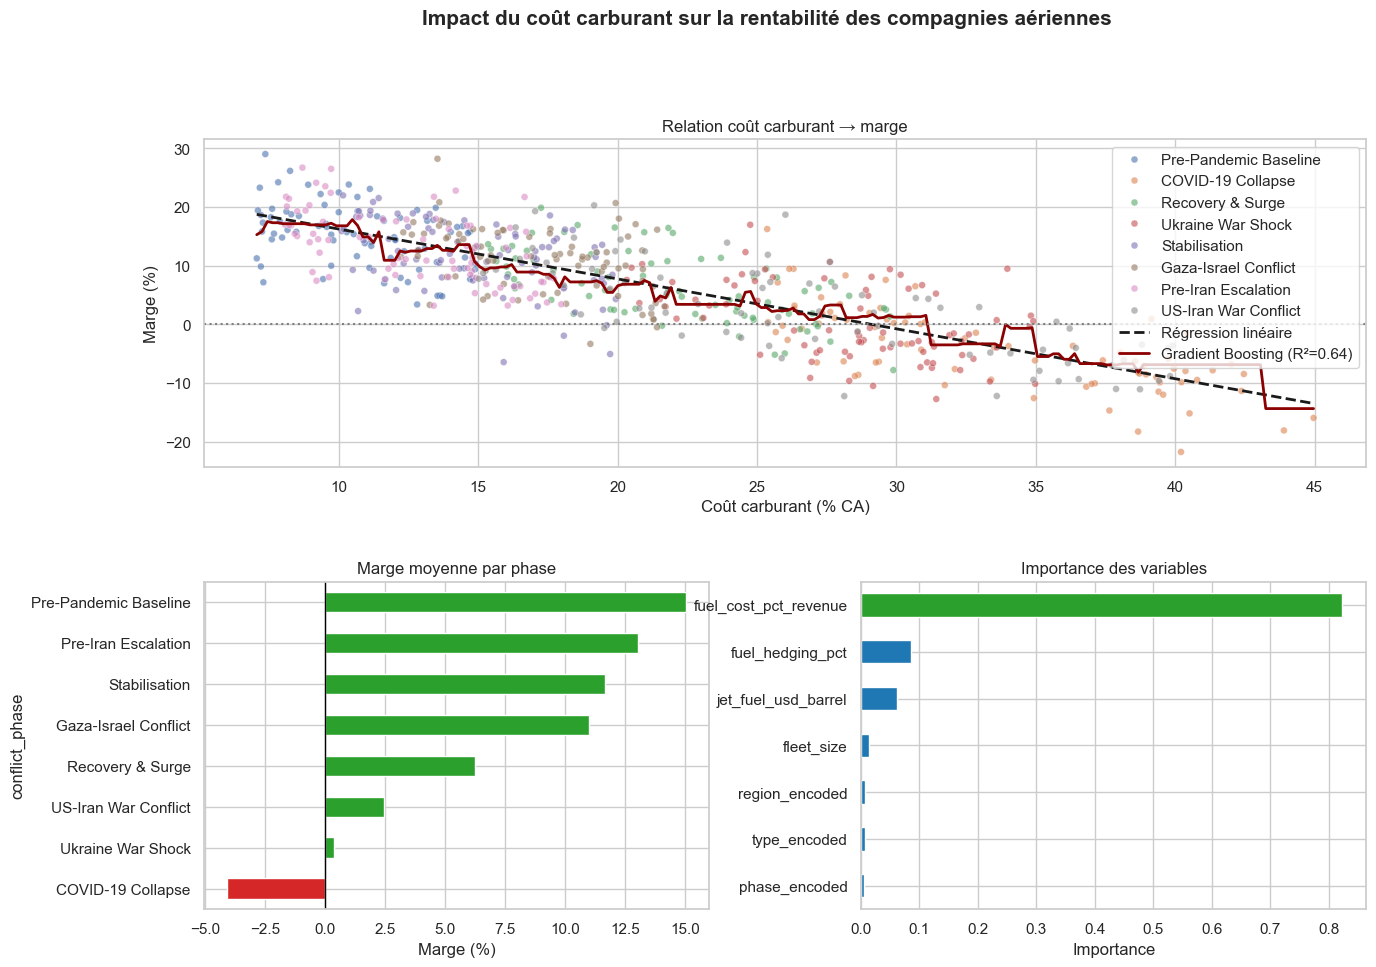

Graphique sauvegardé : resultats_final.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec

# Sécurité : vérifier variables critiques
y_pred_gb = best_model.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

fig.suptitle(
    "Impact du coût carburant sur la rentabilité des compagnies aériennes",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

# --- Graphique 1 ---
ax1 = fig.add_subplot(gs[0, :])

sns.scatterplot(
    data=df,
    x="fuel_cost_pct_revenue",
    y="profit_margin_pct",
    hue="conflict_phase",
    ax=ax1,
    alpha=0.6,
    s=25
)

# Régression simple
x_line = np.linspace(
    df["fuel_cost_pct_revenue"].min(),
    df["fuel_cost_pct_revenue"].max(),
    200
).reshape(-1, 1)

y_line_simple = lr_simple.predict(x_line)
ax1.plot(x_line, y_line_simple, "k--", linewidth=2, label="Régression linéaire")

# Gradient Boosting (robuste)
X_line_full = pd.DataFrame({
    "fuel_cost_pct_revenue": x_line.flatten(),
    "jet_fuel_usd_barrel": df["jet_fuel_usd_barrel"].mean(),
    "fuel_hedging_pct": df["fuel_hedging_pct"].mean(),
    "fleet_size": df["fleet_size"].mean(),
    "phase_encoded": df["phase_encoded"].median(),
    "type_encoded": df["type_encoded"].median(),
    "region_encoded": df["region_encoded"].median(),
})

y_line_gb = best_model.predict(X_line_full)

ax1.plot(
    x_line,
    y_line_gb,
    color="darkred",
    linewidth=2,
    label=f"Gradient Boosting (R²={r2_gb:.2f})"
)

ax1.axhline(0, color="gray", linestyle=":")
ax1.set_title("Relation coût carburant → marge")
ax1.set_xlabel("Coût carburant (% CA)")
ax1.set_ylabel("Marge (%)")
ax1.legend()

# --- Graphique 2 ---
ax2 = fig.add_subplot(gs[1, 0])

phase_means = df.groupby("conflict_phase")["profit_margin_pct"].mean().sort_values()

colors_bar = ["#d62728" if v < 0 else "#2ca02c" for v in phase_means]

phase_means.plot(kind="barh", ax=ax2, color=colors_bar, edgecolor="white")

ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Marge moyenne par phase")
ax2.set_xlabel("Marge (%)")

# --- Graphique 3 ---
ax3 = fig.add_subplot(gs[1, 1])

imp_sorted = importances.sort_values(ascending=True)

colors_imp = [
    "#2ca02c" if "fuel_cost" in f else "#1f77b4"
    for f in imp_sorted.index
]

imp_sorted.plot(
    kind="barh",
    ax=ax3,
    color=colors_imp,
    edgecolor="white"
)

ax3.set_title("Importance des variables")
ax3.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("resultats_final.png", dpi=150)
plt.show()

print("Graphique sauvegardé : resultats_final.png")

## 7. Conclusion & recommandations business

---

### 🔍 Ce que les données montrent

En regardant les résultats, on voit quelque chose d’assez logique :

Quand le carburant coûte plus cher, les compagnies gagnent moins d’argent.

C’est presque une relation directe : plus la part du carburant dans les revenus augmente, plus la marge baisse.

Et pendant les grandes crises (COVID, guerre en Ukraine, tensions géopolitiques), cet effet devient encore plus fort, parce que le prix du pétrole est très instable.

En résumé :
- quand le carburant reste bas → les compagnies s’en sortent correctement
- quand il augmente trop → les marges chutent rapidement

---

### 💡 Ce qu’on peut en tirer

À partir de ça, il y a 3 choses assez simples à retenir.

---

#### 1. Se protéger des variations du carburant (hedging)

Le prix du carburant peut changer très vite, surtout en période de crise.

Certaines compagnies évitent ce risque en achetant une partie du carburant à l’avance à prix fixe.

👉 Ça permet de ne pas subir totalement les hausses.

En pratique, couvrir une partie des besoins (par exemple 40 à 60%) permet de rendre les coûts plus stables.

---

#### 2. Suivre un indicateur simple

Un truc important qu’on voit avec les données, c’est qu’il faut surveiller les bons signaux avant que ça devienne critique.

Un indicateur simple serait :
> la part du carburant dans le chiffre d’affaires

Quand ce ratio monte trop haut, la rentabilité commence à être en danger.

Donc l’idée serait d’avoir un suivi régulier, et d’agir avant que ça devienne trop tard (ajustement des prix, réduction de certaines dépenses, etc.).

---

#### 3. Avoir une flotte plus moderne

Un autre point important, c’est que tous les avions ne consomment pas la même quantité de carburant.

Les avions récents consomment moins, donc ils sont plus rentables sur le long terme.

👉 Même si ça coûte cher au début, remplacer progressivement les avions permet de réduire les coûts carburant dans le temps.

---

### 🎯 Conclusion

Ce que montre ce projet, c’est assez simple :

Le carburant est le facteur principal qui influence la rentabilité des compagnies aériennes.

Mais ce n’est pas un facteur qu’on subit complètement. Avec de la data, du suivi et de bonnes décisions, on peut mieux anticiper les périodes difficiles et limiter l’impact.